# Fetal Health CTG — Exploratory Data Analysis

**Business question:** what seems to cause a CTG (cardiotocogram) recording to be predicted as *pathological*?

**Dataset:** `data/fetal_health.csv` — 2126 CTG recordings, 21 features derived from the SisPorto automated signal-analysis system, plus the label `fetal_health` (1 = Normal, 2 = Suspect, 3 = Pathological).

This notebook works through the plan in four parts:
1. Data quality checks
2. The most informative univariate / bivariate views
3. Likely confounders and biases
4. A prioritized list of what to investigate next


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

# --- palette (validated categorical/ordinal/diverging set) ---------------
INK_PRIMARY   = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED     = '#898781'
GRID          = '#e1e0d9'
BASELINE      = '#c3c2b7'
SURFACE       = '#fcfcfb'

# ordinal severity ramp (single hue, light -> dark): Normal -> Suspect -> Pathological
CLASS_COLORS = {1: '#6da7ec', 2: '#2a78d6', 3: '#104281'}
CLASS_LABELS = {1: 'Normal', 2: 'Suspect', 3: 'Pathological'}

# diverging pair for signed values (correlation, etc.)
DIV_NEG, DIV_MID, DIV_POS = '#104281', '#f0efec', '#e34948'
DIV_CMAP = LinearSegmentedColormap.from_list('div_blue_red', [DIV_NEG, DIV_MID, DIV_POS])

FLAG_COLOR = '#eb6834'   # amber/orange for data-quality flags

plt.rcParams.update({
    'figure.facecolor': SURFACE,
    'axes.facecolor':   SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor':   BASELINE,
    'axes.labelcolor':  INK_SECONDARY,
    'text.color':       INK_PRIMARY,
    'xtick.color':      INK_MUTED,
    'ytick.color':      INK_MUTED,
    'grid.color':       GRID,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.titlecolor':  INK_PRIMARY,
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'axes.grid':        True,
    'grid.linewidth':   0.7,
    'axes.axisbelow':   True,
})

def style_axes(ax):
    ax.spines['left'].set_color(BASELINE)
    ax.spines['bottom'].set_color(BASELINE)
    ax.grid(axis='y', linewidth=0.7, color=GRID)
    ax.set_axisbelow(True)

def class_legend(ax, **kwargs):
    handles = [Patch(facecolor=CLASS_COLORS[k], label=f'{k:.0f} — {CLASS_LABELS[k]}') for k in [1, 2, 3]]
    ax.legend(handles=handles, frameon=False, title='fetal_health', **kwargs)


## Load the data

In [2]:

df = pd.read_csv('data/fetal_health.csv')
print(f'{df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()


2,126 rows x 22 columns


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,10.4,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,13.4,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,23.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


## 1. Data quality checks

Checked first, before trusting any pattern below: missing values, duplicates, dtypes, and features that are so sparse (near-zero variance) that a naive read of them is misleading.


In [3]:

missing = df.isnull().sum()
dtypes = df.dtypes
quality = pd.DataFrame({'dtype': dtypes, 'missing': missing, 'missing_pct': (missing / len(df) * 100).round(2)})
n_dupes = df.duplicated().sum()

print(f'Missing values: {missing.sum()} across all columns')
print(f'Exact duplicate rows: {n_dupes} ({n_dupes/len(df)*100:.1f}% of rows)')
print(f'All columns stored as: {dtypes.unique().tolist()}  <- note: peaks/zeroes/tendency are really counts/ordinal, not continuous')
quality


Missing values: 0 across all columns
Exact duplicate rows: 13 (0.6% of rows)
All columns stored as: [dtype('float64')]  <- note: peaks/zeroes/tendency are really counts/ordinal, not continuous


,dtype,missing,missing_pct
baseline value,float64,0,0.0
accelerations,float64,0,0.0
fetal_movement,float64,0,0.0
uterine_contractions,float64,0,0.0
light_decelerations,float64,0,0.0
severe_decelerations,float64,0,0.0
prolongued_decelerations,float64,0,0.0
abnormal_short_term_variability,float64,0,0.0
mean_value_of_short_term_variability,float64,0,0.0
percentage_of_time_with_abnormal_long_term_variability,float64,0,0.0


In [4]:

# Drop exact duplicates before anything downstream
df = df.drop_duplicates().reset_index(drop=True)
print(f'Working set after dropping duplicates: {len(df):,} rows')


Working set after dropping duplicates: 2,113 rows


**Class balance.** `fetal_health` is heavily imbalanced. Pathological is the class the business question is about, and it is also the smallest — every downstream pattern on it rests on ~8% of the data.


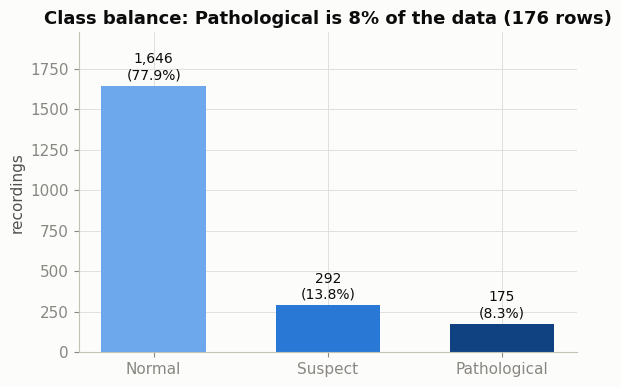

In [5]:

counts = df['fetal_health'].value_counts().sort_index()
pct = (counts / counts.sum() * 100)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([CLASS_LABELS[k] for k in counts.index], counts.values,
              color=[CLASS_COLORS[k] for k in counts.index], width=0.6)
for b, c, p in zip(bars, counts.values, pct.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 20, f'{c:,}\n({p:.1f}%)',
            ha='center', va='bottom', fontsize=10, color=INK_PRIMARY)
style_axes(ax)
ax.set_ylim(0, counts.max() * 1.2)
ax.set_ylabel('recordings')
ax.set_title('Class balance: Pathological is 8% of the data (176 rows)')
plt.tight_layout()
plt.show()


**Sparse / near-zero-variance features.** Several deceleration and movement counts are zero for most recordings. Their *mean* looks negligible, which understates their signal — `prolongued_decelerations` is nonzero in only 8% of rows but is the single strongest correlate of pathology (see section 2). `severe_decelerations` is nonzero in 0.3% of rows — effectively no variance, likely uninformative at this sample size no matter what statistic is used on it.


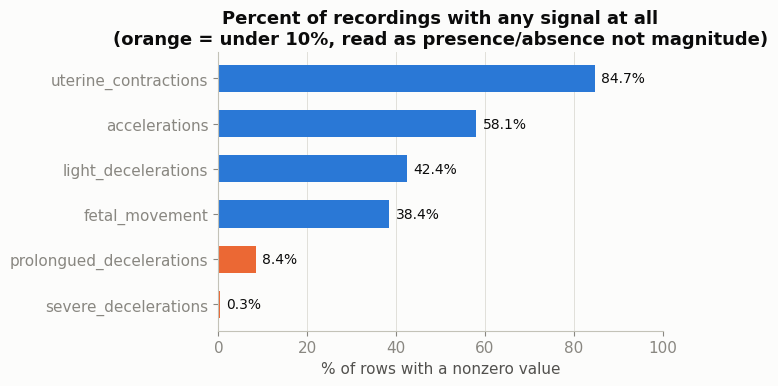

In [6]:

sparse_cols = ['accelerations', 'fetal_movement', 'uterine_contractions',
               'light_decelerations', 'prolongued_decelerations', 'severe_decelerations']
nonzero_rate = (df[sparse_cols] > 0).mean().sort_values() * 100

fig, ax = plt.subplots(figsize=(7, 4))
colors = [FLAG_COLOR if r < 10 else '#2a78d6' for r in nonzero_rate.values]
bars = ax.barh(nonzero_rate.index, nonzero_rate.values, color=colors, height=0.6)
for b, v in zip(bars, nonzero_rate.values):
    ax.text(v + 1.5, b.get_y() + b.get_height() / 2, f'{v:.1f}%', va='center', fontsize=10, color=INK_PRIMARY)
style_axes(ax)
ax.grid(axis='x', linewidth=0.7, color=GRID)
ax.grid(axis='y', visible=False)
ax.set_xlim(0, 100)
ax.set_xlabel('% of rows with a nonzero value')
ax.set_title('Percent of recordings with any signal at all\n(orange = under 10%, read as presence/absence not magnitude)')
plt.tight_layout()
plt.show()


## 2. Most informative univariate / bivariate views

Ranked by how strongly each pattern separates the three classes (see the correlation view at the end of this section for the full ranking).


### 2.1 Short-term variability abnormality — the cleanest single separator

`abnormal_short_term_variability` has the highest correlation with `fetal_health` (r ≈ 0.47) and shows a clean, monotonic step up from Normal to Pathological.


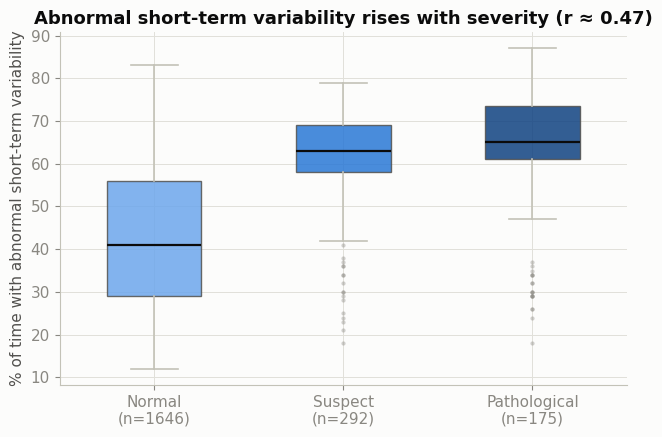

In [7]:

fig, ax = plt.subplots(figsize=(6.5, 4.5))
data = [df.loc[df.fetal_health == k, 'abnormal_short_term_variability'] for k in [1, 2, 3]]
bp = ax.boxplot(data, patch_artist=True, widths=0.5, showfliers=True,
                 medianprops=dict(color=INK_PRIMARY, linewidth=1.6),
                 whiskerprops=dict(color=BASELINE, linewidth=1.2),
                 capprops=dict(color=BASELINE, linewidth=1.2),
                 boxprops=dict(linewidth=1.0, edgecolor=INK_SECONDARY),
                 flierprops=dict(marker='o', markersize=3, markerfacecolor=INK_MUTED,
                                  markeredgecolor='none', alpha=0.4))
for patch, k in zip(bp['boxes'], [1, 2, 3]):
    patch.set_facecolor(CLASS_COLORS[k])
    patch.set_alpha(0.85)
ax.set_xticklabels([f'{CLASS_LABELS[k]}\n(n={sum(df.fetal_health==k)})' for k in [1, 2, 3]])
style_axes(ax)
ax.set_ylabel('% of time with abnormal short-term variability')
ax.set_title('Abnormal short-term variability rises with severity (r ≈ 0.47)')
plt.tight_layout()
plt.show()


### 2.2 Long-term variability abnormality — not simply monotonic

`percentage_of_time_with_abnormal_long_term_variability` correlates almost as strongly (r ≈ 0.43), but Suspect (29%) is *higher* on average than Pathological (23%) — Suspect is not just "a bit less than Pathological," which is worth flagging before assuming these classes sit on one continuous scale.


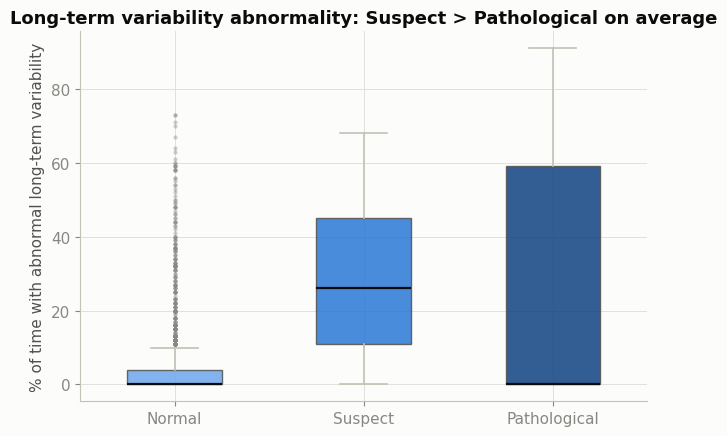

In [8]:

fig, ax = plt.subplots(figsize=(6.5, 4.5))
data = [df.loc[df.fetal_health == k, 'percentage_of_time_with_abnormal_long_term_variability'] for k in [1, 2, 3]]
bp = ax.boxplot(data, patch_artist=True, widths=0.5, showfliers=True,
                 medianprops=dict(color=INK_PRIMARY, linewidth=1.6),
                 whiskerprops=dict(color=BASELINE, linewidth=1.2),
                 capprops=dict(color=BASELINE, linewidth=1.2),
                 boxprops=dict(linewidth=1.0, edgecolor=INK_SECONDARY),
                 flierprops=dict(marker='o', markersize=3, markerfacecolor=INK_MUTED,
                                  markeredgecolor='none', alpha=0.4))
for patch, k in zip(bp['boxes'], [1, 2, 3]):
    patch.set_facecolor(CLASS_COLORS[k])
    patch.set_alpha(0.85)
ax.set_xticklabels([CLASS_LABELS[k] for k in [1, 2, 3]])
style_axes(ax)
ax.set_ylabel('% of time with abnormal long-term variability')
ax.set_title('Long-term variability abnormality: Suspect > Pathological on average')
plt.tight_layout()
plt.show()


### 2.3 Prolonged decelerations — read as presence, not magnitude

Only 8% of recordings have *any* prolonged deceleration, so the mean value is close to zero for every class. The presence rate tells the real story: it climbs sharply with severity.


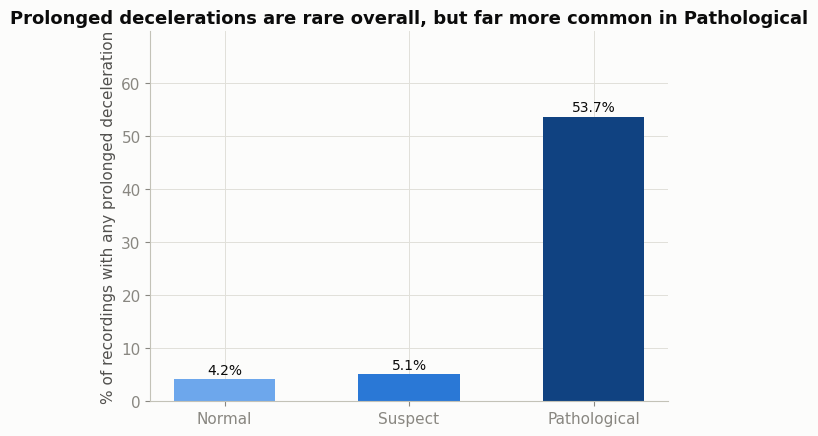

In [9]:

presence_rate = df.groupby('fetal_health').apply(
    lambda g: (g['prolongued_decelerations'] > 0).mean() * 100, include_groups=False
)
fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar([CLASS_LABELS[k] for k in presence_rate.index], presence_rate.values,
              color=[CLASS_COLORS[k] for k in presence_rate.index], width=0.55)
for b, v in zip(bars, presence_rate.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f'{v:.1f}%', ha='center', fontsize=10, color=INK_PRIMARY)
style_axes(ax)
ax.set_ylim(0, max(presence_rate.values) * 1.3)
ax.set_ylabel('% of recordings with any prolonged deceleration')
ax.set_title('Prolonged decelerations are rare overall, but far more common in Pathological')
plt.tight_layout()
plt.show()


### 2.4 Histogram center-of-mass — Pathological breaks the trend

`histogram_mode`, `histogram_mean` and `histogram_median` all describe the same thing (the center of the fetal heart-rate histogram) and move together. Normal → Suspect rises, but Pathological drops well below both — the opposite direction. That inversion is a strong hint that "Pathological" bundles more than one underlying pattern (confirmed formally in section 2.6, discussed in section 5).


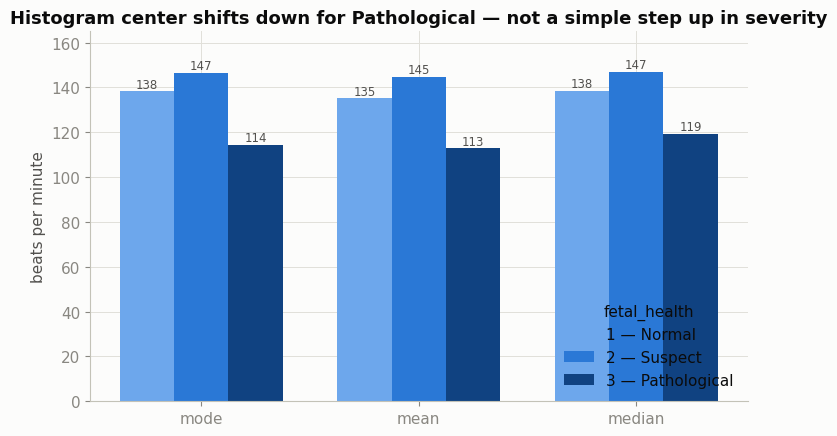

In [10]:

metrics = ['histogram_mode', 'histogram_mean', 'histogram_median']
means = df.groupby('fetal_health')[metrics].mean()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(len(metrics))
width = 0.25
for i, k in enumerate([1, 2, 3]):
    vals = means.loc[k, metrics].values
    bars = ax.bar(x + (i - 1) * width, vals, width=width, color=CLASS_COLORS[k], label=CLASS_LABELS[k])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f'{v:.0f}', ha='center', fontsize=8.5, color=INK_SECONDARY)
ax.set_xticks(x)
ax.set_xticklabels(['mode', 'mean', 'median'])
style_axes(ax)
ax.set_ylabel('beats per minute')
ax.set_ylim(0, 165)
class_legend(ax, loc='lower right')
ax.set_title('Histogram center shifts down for Pathological — not a simple step up in severity')
plt.tight_layout()
plt.show()


### 2.5 Two variability measures together — does Pathological form one cluster or two?

Plotting short-term variability abnormality against long-term variability level shows whether the Pathological class is one coherent group or splits into separate patterns.


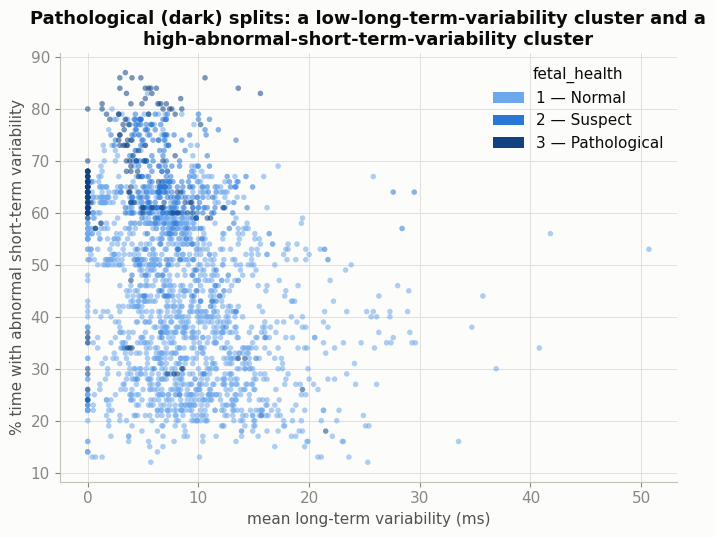

In [11]:

fig, ax = plt.subplots(figsize=(7, 5.5))
for k in [1, 2, 3]:
    sub = df[df.fetal_health == k]
    ax.scatter(sub['mean_value_of_long_term_variability'], sub['abnormal_short_term_variability'],
               s=16, color=CLASS_COLORS[k], alpha=0.55, edgecolors='none', label=CLASS_LABELS[k])
style_axes(ax)
ax.set_xlabel('mean long-term variability (ms)')
ax.set_ylabel('% time with abnormal short-term variability')
class_legend(ax, loc='upper right')
ax.set_title('Pathological (dark) splits: a low-long-term-variability cluster and a\nhigh-abnormal-short-term-variability cluster')
plt.tight_layout()
plt.show()


### 2.6 Does Pathological actually split into coherent subgroups?

Section 2.5 raised the hypothesis by eye. Here it is tested formally: cluster the 175 Pathological recordings on the variability- and histogram-shape features, pick `k` by silhouette score, and check the result against a null baseline (the same clustering procedure applied to a same-size random sample of Normal recordings — if Pathological clusters no better than an arbitrary group, the "two subtypes" idea does not hold up).


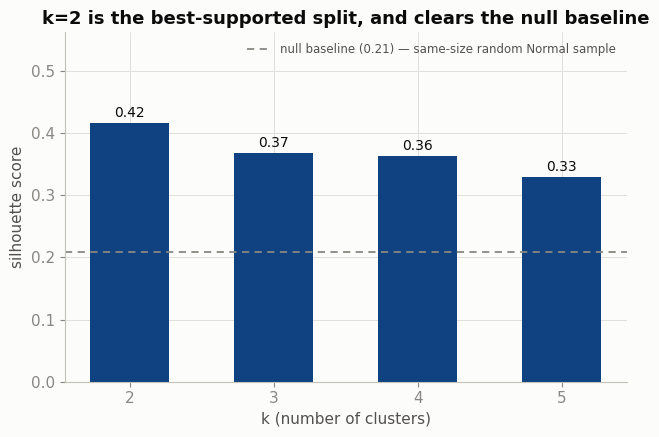

silhouette by k: {2: 0.417, 3: 0.368, 4: 0.364, 5: 0.329}
null baseline (Normal, same size, k=2): 0.208  [range 0.183-0.226]


In [12]:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

cluster_feats = ['abnormal_short_term_variability', 'mean_value_of_short_term_variability',
                  'percentage_of_time_with_abnormal_long_term_variability',
                  'mean_value_of_long_term_variability', 'histogram_mode', 'baseline value',
                  'prolongued_decelerations', 'histogram_variance']

path = df[df.fetal_health == 3].copy()
Xp = StandardScaler().fit_transform(path[cluster_feats])

sil_by_k = {}
for k in [2, 3, 4, 5]:
    labels = KMeans(n_clusters=k, n_init=20, random_state=0).fit_predict(Xp)
    sil_by_k[k] = silhouette_score(Xp, labels)

# null baseline: same procedure, same sample size, drawn from Normal instead of Pathological
normal_pool = df[df.fetal_health == 1]
null_sils = []
for seed in range(20):
    samp = normal_pool.sample(n=len(path), random_state=seed)
    Xn = StandardScaler().fit_transform(samp[cluster_feats])
    labels_n = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(Xn)
    null_sils.append(silhouette_score(Xn, labels_n))
null_mean = np.mean(null_sils)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ks = list(sil_by_k.keys())
vals = list(sil_by_k.values())
bars = ax.bar([str(k) for k in ks], vals, color=CLASS_COLORS[3], width=0.55)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.2f}', ha='center', fontsize=10, color=INK_PRIMARY)
ax.axhline(null_mean, color=INK_MUTED, linewidth=1.3, linestyle=(0, (4, 3)),
           label=f'null baseline ({null_mean:.2f}) — same-size random Normal sample')
ax.legend(frameon=False, loc='upper right', fontsize=8.5, labelcolor=INK_SECONDARY)
style_axes(ax)
ax.set_ylim(0, max(vals) * 1.35)
ax.set_xlabel('k (number of clusters)')
ax.set_ylabel('silhouette score')
ax.set_title('k=2 is the best-supported split, and clears the null baseline')
plt.tight_layout()
plt.show()

print('silhouette by k:', {k: round(v, 3) for k, v in sil_by_k.items()})
print(f'null baseline (Normal, same size, k=2): {null_mean:.3f}  [range {min(null_sils):.3f}-{max(null_sils):.3f}]')


`k=2` scores highest (silhouette ≈ 0.42) and comfortably clears the null baseline (≈0.21 for a same-size random slice of Normal recordings put through the same procedure) — Pathological clusters roughly twice as cleanly as an arbitrary group of that size would, so this is a real structure, not an artifact of clustering any 175 points.


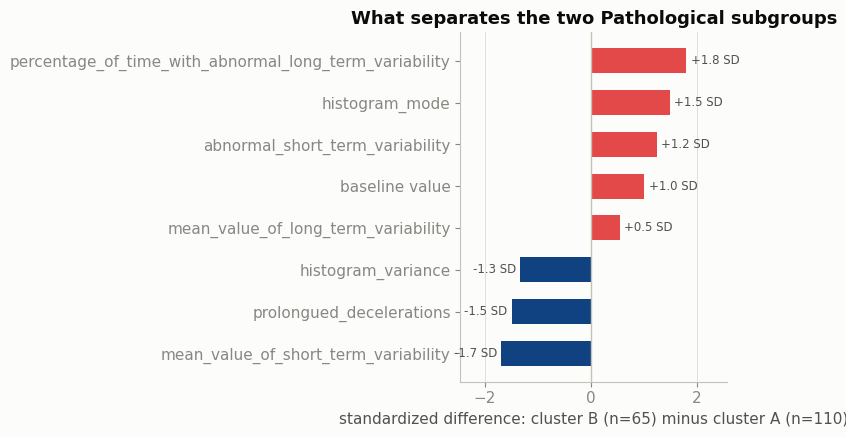

In [13]:

km2 = KMeans(n_clusters=2, n_init=20, random_state=0).fit(Xp)
path['cluster'] = km2.labels_
sizes = path['cluster'].value_counts().sort_index()

# z-score against the real within-Pathological-class spread (Xp), not just the 2 cluster means
Xp_df = pd.DataFrame(Xp, columns=cluster_feats, index=path.index)
Xp_df['cluster'] = path['cluster'].values
z = Xp_df.groupby('cluster')[cluster_feats].mean()
diff = (z.loc[1] - z.loc[0]).sort_values()   # + means higher in cluster 1, in within-class SD units

fig, ax = plt.subplots(figsize=(7.5, 4.5))
colors = [DIV_POS if v > 0 else DIV_NEG for v in diff.values]
bars = ax.barh(diff.index, diff.values, color=colors, height=0.6)
for b, v in zip(bars, diff.values):
    ax.text(v + (0.08 if v >= 0 else -0.08), b.get_y() + b.get_height() / 2, f'{v:+.1f} SD',
            va='center', ha='left' if v >= 0 else 'right', fontsize=8.5, color=INK_SECONDARY)
ax.axvline(0, color=BASELINE, linewidth=1)
style_axes(ax)
ax.grid(axis='y', visible=False)
lo, hi = diff.values.min(), diff.values.max()
pad = (hi - lo) * 0.22
ax.set_xlim(lo - pad, hi + pad)
ax.set_xlabel(f'standardized difference: cluster B (n={sizes[1]}) minus cluster A (n={sizes[0]})')
ax.set_title('What separates the two Pathological subgroups')
plt.tight_layout()
plt.show()


**Cluster A (n=110) — low baseline, erratic trace.** Low baseline heart rate (≈128 bpm) and low histogram mode (≈100 bpm), but high `histogram_variance` — a wide, ragged heart-rate histogram rather than a flat one. Long-term variability is almost never flagged abnormal (≈0%).

**Cluster B (n=65) — flat trace, sustained abnormal long-term variability.** Baseline and histogram mode sit closer to the Normal/Suspect range (≈138 bpm), but `percentage_of_time_with_abnormal_long_term_variability` is high (≈61% of the recording) and `histogram_variance` collapses to near zero (≈0.4) — a narrow, flat-looking trace held in an abnormal state for most of the recording, with reduced short-term variability alongside it.

These read as two distinct, clinically-recognizable non-reassuring patterns — a low/erratic-baseline pattern and a flat/sustained-abnormal-variability pattern — rather than two points on the same severity scale. `prolongued_decelerations` is small in absolute terms either way (cluster A mean ≈0.002, cluster B exactly 0), but the split is clean: every prolonged deceleration in the Pathological class sits in cluster A. It looks like a marker of pathology in general (section 2.3) that, within Pathological, concentrates entirely in one subtype.


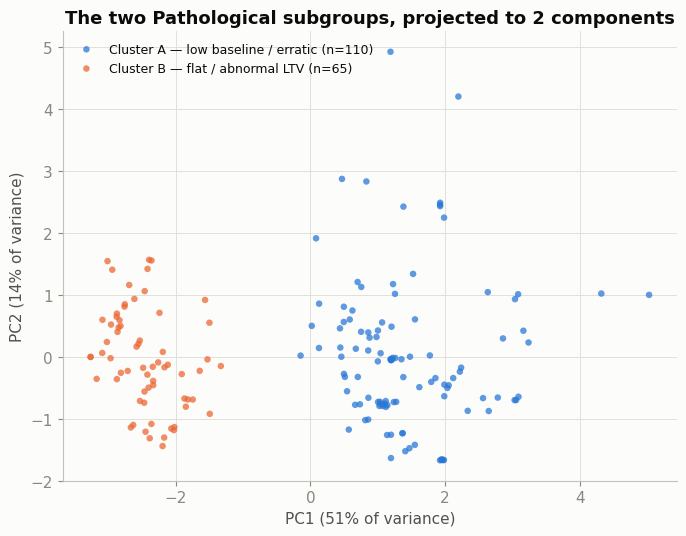

In [14]:

pca = PCA(n_components=2, random_state=0)
pcs = pca.fit_transform(Xp)
cluster_palette = {0: '#2a78d6', 1: '#eb6834'}   # categorical identity, not severity — distinct from the class ramp
cluster_names = {0: f'Cluster A — low baseline / erratic (n={sizes[0]})',
                  1: f'Cluster B — flat / abnormal LTV (n={sizes[1]})'}

fig, ax = plt.subplots(figsize=(7, 5.5))
for c in [0, 1]:
    mask = path['cluster'].values == c
    ax.scatter(pcs[mask, 0], pcs[mask, 1], s=22, color=cluster_palette[c], alpha=0.75,
               edgecolors='none', label=cluster_names[c])
style_axes(ax)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% of variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% of variance)')
ax.legend(frameon=False, loc='best', fontsize=9)
ax.set_title('The two Pathological subgroups, projected to 2 components')
plt.tight_layout()
plt.show()


**Does the split survive a different clustering method?** K-means makes a spherical-cluster assumption. A quick cross-check with two methods that don't share that assumption — Gaussian mixture (allows elliptical clusters) and agglomerative/Ward clustering (no distributional assumption at all) — tests whether the 2-group structure is a k-means artifact or something the data actually supports.


In [15]:

from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

agg_labels = AgglomerativeClustering(n_clusters=2, linkage='ward').fit_predict(Xp)
gmm_labels = GaussianMixture(n_components=2, random_state=0, n_init=10).fit_predict(Xp)

ari_km_agg = adjusted_rand_score(km2.labels_, agg_labels)
ari_km_gmm = adjusted_rand_score(km2.labels_, gmm_labels)

agreement = pd.DataFrame({
    'method': ['Gaussian mixture', 'Agglomerative (Ward)'],
    'cluster sizes': [str(np.bincount(gmm_labels).tolist()), str(np.bincount(agg_labels).tolist())],
    'agreement with k-means (ARI)': [ari_km_gmm, ari_km_agg],
})
agreement


,method,cluster sizes,agreement with k-means (ARI)
0,Gaussian mixture,"[110, 65]",1.000000
1,Agglomerative (Ward),"[115, 60]",0.887703


**Answer: yes — and it holds up.** Pathological is not one coherent group — it is (at least) two, supported three ways: the silhouette score clears the null baseline (previous view), and two methods with different assumptions (Gaussian mixture, Ward clustering) land on essentially the same partition as k-means (adjusted Rand index ≈0.89–1.00, where 1.0 is a perfect match). This is not a k-means artifact. Any explanation of "what causes a Pathological prediction" should treat these as two separate stories rather than averaging across them.


### 2.7 Ranking every feature's association with the label

A single view to prioritize the rest: Pearson correlation of every feature against `fetal_health` (1/2/3 treated as an ordinal scale). Read this as a screening tool, not causal evidence — sparse features (marked with a dagger) are understated here because a mean-based correlation buries a rare but decisive signal.


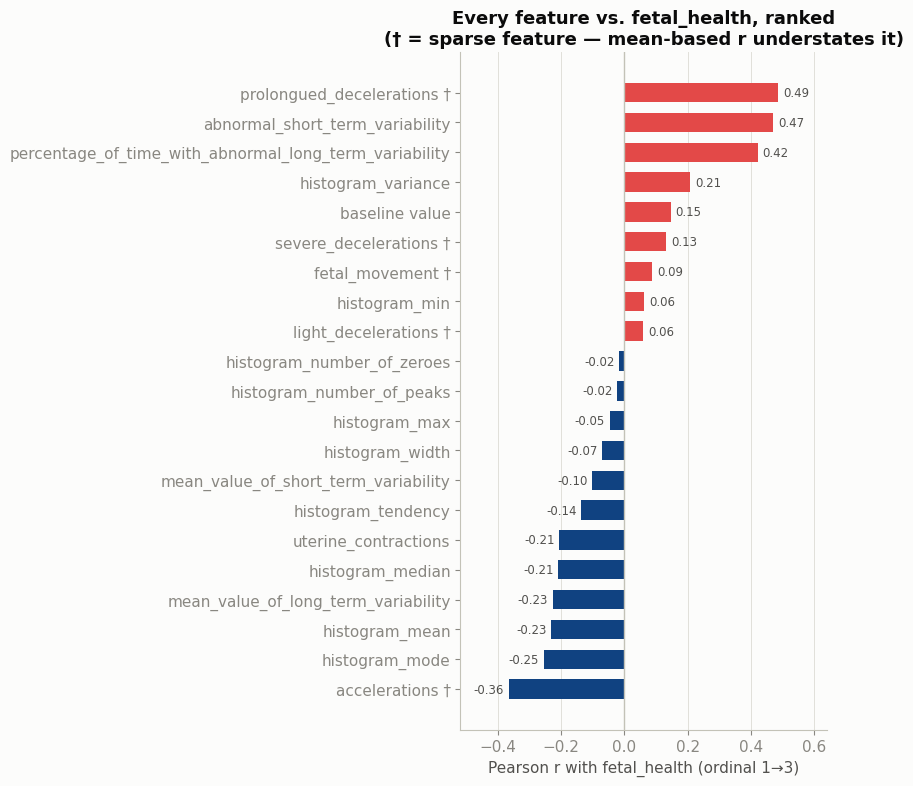

In [16]:

corr = df.corr(numeric_only=True)['fetal_health'].drop('fetal_health').sort_values()
sparse_flagged = {'prolongued_decelerations', 'severe_decelerations', 'light_decelerations',
                   'fetal_movement', 'accelerations'}
labels = [f'{c} †' if c in sparse_flagged else c for c in corr.index]
colors = [DIV_POS if v > 0 else DIV_NEG for v in corr.values]

fig, ax = plt.subplots(figsize=(8.5, 8))
bars = ax.barh(labels, corr.values, color=colors, height=0.65)
for b, v in zip(bars, corr.values):
    ax.text(v + (0.015 if v >= 0 else -0.015), b.get_y() + b.get_height() / 2, f'{v:.2f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=8.5, color=INK_SECONDARY)
ax.axvline(0, color=BASELINE, linewidth=1)
style_axes(ax)
ax.grid(axis='y', visible=False)
lo, hi = corr.values.min(), corr.values.max()
pad = (hi - lo) * 0.18
ax.set_xlim(lo - pad, hi + pad)
ax.set_xlabel('Pearson r with fetal_health (ordinal 1→3)')
ax.set_title('Every feature vs. fetal_health, ranked\n(† = sparse feature — mean-based r understates it)')
plt.tight_layout()
plt.show()


### 2.8 Redundancy among the histogram features

`histogram_mode`, `histogram_mean` and `histogram_median` are near-duplicates of one signal — useful to know before treating each as independent evidence in a model.


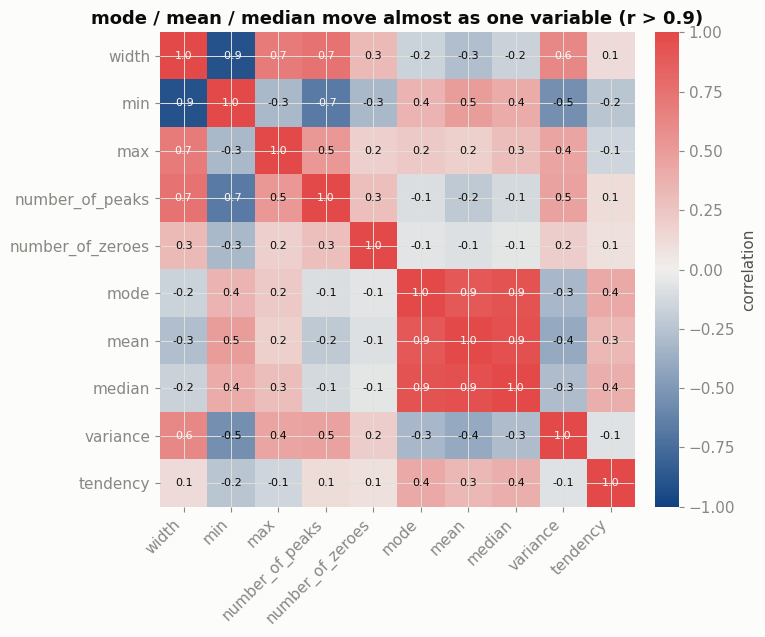

In [17]:

hist_cols = [c for c in df.columns if c.startswith('histogram_')]
hc = df[hist_cols].corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(hc.values, cmap=DIV_CMAP, vmin=-1, vmax=1)
ax.set_xticks(range(len(hist_cols)))
ax.set_yticks(range(len(hist_cols)))
ax.set_xticklabels([c.replace('histogram_', '') for c in hist_cols], rotation=45, ha='right')
ax.set_yticklabels([c.replace('histogram_', '') for c in hist_cols])
for i in range(len(hist_cols)):
    for j in range(len(hist_cols)):
        v = hc.values[i, j]
        txt_color = INK_PRIMARY if abs(v) < 0.6 else SURFACE
        ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=8, color=txt_color)
ax.spines[:].set_visible(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('correlation')
ax.set_title('mode / mean / median move almost as one variable (r > 0.9)')
plt.tight_layout()
plt.show()


### 2.9 Are the sparse deceleration flags real signal, or noise from rare events?

`prolongued_decelerations` and `severe_decelerations` are near-zero for most recordings (section 1), so their raw correlation understates them. Tested properly here as presence/absence against class: a chi-square test for `prolongued_decelerations` (cell counts are large enough for it to be reliable), and Fisher's exact test for `severe_decelerations` (only 7 recordings have one at all, so chi-square's usual assumptions do not hold).


In [18]:

from scipy.stats import chi2_contingency, fisher_exact

results = []

# prolongued_decelerations: cell counts are large enough for chi-square
flag = (df['prolongued_decelerations'] > 0).astype(int)
ct = pd.crosstab(flag, df['fetal_health'])
chi2, p, dof, expected = chi2_contingency(ct)
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
results.append(['prolongued_decelerations', 'chi-square', f'χ²={chi2:.1f}, p={p:.1e}', f"Cramer's V={cramers_v:.2f}"])

# severe_decelerations: too sparse for chi-square (expected count < 5 in a cell) -> Fisher exact, collapsed to Pathological vs not
flag_s = (df['severe_decelerations'] > 0).astype(int)
is_path = (df['fetal_health'] == 3).astype(int)
ct_s = pd.crosstab(flag_s, is_path)
odds, p_s = fisher_exact(ct_s)
results.append(['severe_decelerations', "Fisher's exact (Pathological vs. not)", f'odds ratio={odds:.1f}, p={p_s:.1e}',
                 f'only {int(flag_s.sum())} recordings nonzero — treat as suggestive, not precise'])

pd.DataFrame(results, columns=['feature', 'test used', 'result', 'note'])


,feature,test used,result,note
0,prolongued_decelerations,chi-square,"χ²=507.6, p=5.9e-111",Cramer's V=0.49
1,severe_decelerations,Fisher's exact (Pathological vs. not),"odds ratio=68.8, p=1.9e-06",only 7 recordings nonzero — treat as suggestiv...


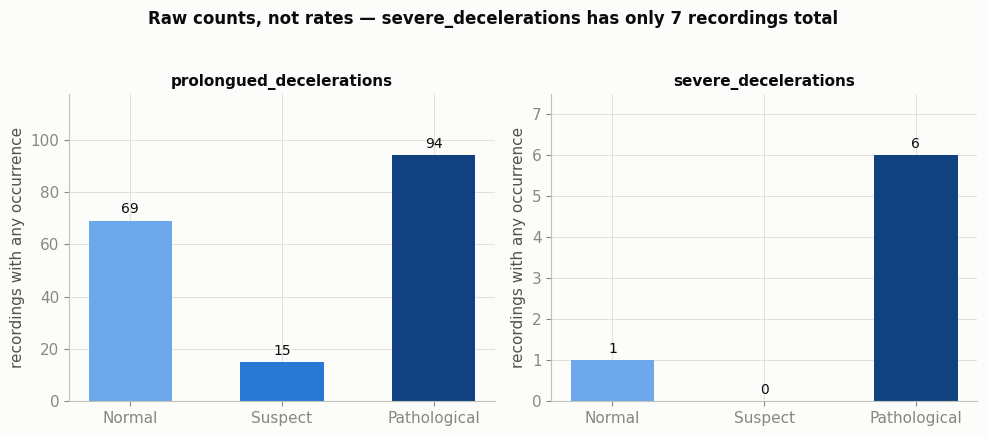

In [19]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, col in zip(axes, ['prolongued_decelerations', 'severe_decelerations']):
    counts = df[df[col] > 0].groupby('fetal_health').size().reindex([1, 2, 3], fill_value=0)
    bars = ax.bar([CLASS_LABELS[k] for k in counts.index], counts.values,
                  color=[CLASS_COLORS[k] for k in counts.index], width=0.55)
    for b, v in zip(bars, counts.values):
        ax.text(b.get_x() + b.get_width() / 2, v + max(counts.values) * 0.03, f'{v:.0f}',
                ha='center', fontsize=10, color=INK_PRIMARY)
    style_axes(ax)
    ax.set_ylim(0, max(counts.values) * 1.25)
    ax.set_ylabel('recordings with any occurrence')
    ax.set_title(col, fontsize=11)
fig.suptitle('Raw counts, not rates — severe_decelerations has only 7 recordings total', fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


**Both hold up, with different confidence.** `prolongued_decelerations` is a strong, reliable signal (Cramér's V ≈0.49, matching its correlation rank in section 2.7). `severe_decelerations` shows a large odds ratio (≈69×) and a significant p-value, but that rests on 6 Pathological cases out of 7 total — real evidence, but not enough to trust the exact odds ratio; more useful as "essentially never happens outside Pathological" than as a precise effect size.


### 2.10 Is `histogram_number_of_zeroes` signal, or a measurement artifact?

If this were a real severity marker it should climb with class the way section 2.1's feature does. If it is a side effect of how the histogram is binned, it should instead track histogram *shape* features like width, regardless of class.


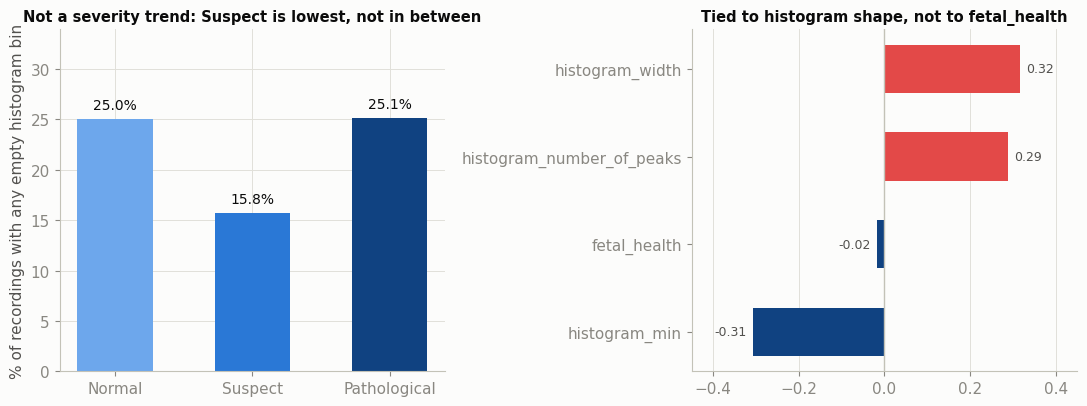

In [20]:

zero_rate = df.groupby('fetal_health').apply(lambda g: (g['histogram_number_of_zeroes'] > 0).mean() * 100,
                                              include_groups=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
bars = ax.bar([CLASS_LABELS[k] for k in zero_rate.index], zero_rate.values,
              color=[CLASS_COLORS[k] for k in zero_rate.index], width=0.55)
for b, v in zip(bars, zero_rate.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f'{v:.1f}%', ha='center', fontsize=10, color=INK_PRIMARY)
style_axes(ax)
ax.set_ylim(0, max(zero_rate.values) * 1.35)
ax.set_ylabel('% of recordings with any empty histogram bin')
ax.set_title('Not a severity trend: Suspect is lowest, not in between', fontsize=10.5)

ax = axes[1]
shape_corr = df.corr(numeric_only=True)['histogram_number_of_zeroes'].drop('histogram_number_of_zeroes')
top = shape_corr.reindex(['histogram_width', 'histogram_min', 'histogram_number_of_peaks', 'fetal_health']).sort_values()
colors = [DIV_POS if v > 0 else DIV_NEG for v in top.values]
bars = ax.barh(top.index, top.values, color=colors, height=0.55)
for b, v in zip(bars, top.values):
    ax.text(v + (0.015 if v >= 0 else -0.015), b.get_y() + b.get_height() / 2, f'{v:.2f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9, color=INK_SECONDARY)
ax.axvline(0, color=BASELINE, linewidth=1)
style_axes(ax)
ax.grid(axis='y', visible=False)
ax.set_xlim(-0.45, 0.45)
ax.set_title('Tied to histogram shape, not to fetal_health', fontsize=10.5)
plt.tight_layout()
plt.show()


**Artifact, not signal.** The presence rate is U-shaped across class (Normal 25.0%, Suspect 15.8%, Pathological 25.1% — a significant difference, χ²  p≈0.002, but not a severity trend), and its correlation with `fetal_health` itself is negligible (r≈-0.02, section 2.7). What it does correlate with is `histogram_width` (r≈0.32) and `histogram_min` (r≈-0.31) — a wider heart-rate histogram simply has more sparsely-populated bins. Read this as a by-product of histogram binning, not a genuine fetal signal, and don't feed it into a model as if it were clinically meaningful on its own.


## 4. Modeling readiness: why the class imbalance needs a stratified split

The next stage after this EDA is modeling, and there is a concrete, checkable risk worth showing rather than just asserting: with only 175 Pathological recordings (further split into two subgroups, section 2.6), an ordinary random train/test split can land very different numbers of them in the test set from run to run — enough to swing a reported recall or F1 score without any real change in the model.


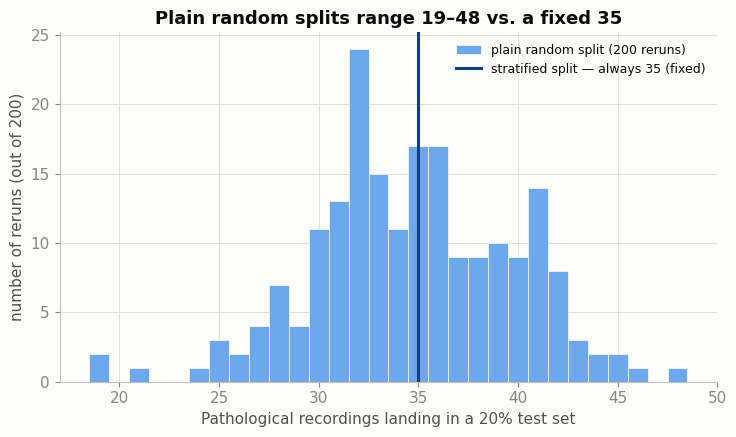

random split: mean=34.7, std=5.0, range=[19, 48]
stratified split: always 35 (20% of 175, exactly)


In [21]:

from sklearn.model_selection import train_test_split

y = df['fetal_health']
random_counts, strat_counts = [], []
for seed in range(200):
    _, test_r = train_test_split(df, test_size=0.2, random_state=seed, shuffle=True)
    random_counts.append((test_r['fetal_health'] == 3).sum())
    _, test_s = train_test_split(df, test_size=0.2, random_state=seed, stratify=y)
    strat_counts.append((test_s['fetal_health'] == 3).sum())
random_counts = np.array(random_counts)
strat_fixed = strat_counts[0]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bins = np.arange(random_counts.min() - 0.5, random_counts.max() + 1.5, 1)
ax.hist(random_counts, bins=bins, color=CLASS_COLORS[1], edgecolor=SURFACE, linewidth=0.5,
        label='plain random split (200 reruns)')
ax.axvline(strat_fixed, color=CLASS_COLORS[3], linewidth=2.2,
           label=f'stratified split — always {strat_fixed} (fixed)')
style_axes(ax)
ax.set_xlabel('Pathological recordings landing in a 20% test set')
ax.set_ylabel('number of reruns (out of 200)')
ax.legend(frameon=False, loc='upper right', fontsize=9)
ax.set_title(f'Plain random splits range {random_counts.min()}–{random_counts.max()} vs. a fixed {strat_fixed}')
plt.tight_layout()
plt.show()

print(f'random split: mean={random_counts.mean():.1f}, std={random_counts.std():.1f}, range=[{random_counts.min()}, {random_counts.max()}]')
print(f'stratified split: always {strat_fixed} (20% of 175, exactly)')


Across 200 reruns, a plain random 80/20 split puts anywhere from 19 to 48 Pathological recordings in the test set (expected ≈35); `train_test_split(..., stratify=y)` pins it at exactly 35 every time. For evaluation metrics on the minority class specifically, that is the difference between a stable read and one that depends on a random seed. The same logic extends to cross-validation (`StratifiedKFold` rather than `KFold`), and — given section 2.6 — it is worth at least checking whether the two Pathological subgroups end up reasonably balanced across folds too, since a model could quietly learn one subtype better than the other.


## 5. Likely confounders or biases

- **Small positive class, smaller still once split.** 175 Pathological rows split into subgroups of  110 and 65 (section 2.6) — real, but each subgroup's profile should still be treated as provisional  given the sample size.
- **No clinical context in the data.** There is no gestational age, maternal risk factors, or  monitoring duration. `fetal_health` is a label on the *CTG trace pattern* (from the SisPorto  system), not a confirmed clinical outcome — this analysis explains what predicts the label, not  what causes fetal distress.
- **Recording length is invisible.** These are per-recording summary statistics. A longer recording  has more opportunity to register a prolonged deceleration, so part of `prolongued_decelerations`'  strength could reflect monitoring duration rather than severity.
- **Histogram features are collinear.** `mode`, `mean` and `median` are three views of one signal  (section 2.8) — they should not be read as three independent pieces of evidence.
- **The Pathological label bundles two mechanisms, confirmed.** Section 2.6 shows this formally:  Pathological splits into a low-baseline/erratic-histogram subgroup and a flat-trace/abnormal-long-term-  variability subgroup. Any "what causes pathological" conclusion drawn from the pooled class average  is really a blend of two different stories — feature importance, thresholds, or a model trained on  the pooled label should be checked separately on each subgroup.
- **The sparse deceleration features carry real signal, at different confidence levels.** Section 2.9  confirms `prolongued_decelerations` statistically (Cramér's V ≈0.49); `severe_decelerations` is  significant too, but the entire effect rests on 6 Pathological cases — a real pattern, not a precise  one.
